# Experiment with RNN (CINC 22)

## Set paths, additional functions and import packages

**Set paths and functions**

In [1]:
root_logdir = '../Logs/'
data_dir = '../Data'
figs_dir = 'Figs/'
models_dir = '../Models/'

**Set functions**

In [2]:
# Tensorboard logs name generator
def get_run_logdir():
    run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")
    return os.path.join(root_logdir, run_id)

**Import packages**

In [3]:
import os
import time
import tensorflow as tf
import keras
from keras import models, layers
#import tensorflow_addons as tfa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.utils import shuffle
from itertools import product
from tools import *
from generators import *
from sklearn.model_selection import train_test_split,KFold
checkpoint_filepath = models_dir+'RNN_model_check'

2025-04-03 15:49:27.421763: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-03 15:49:27.499426: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-03 15:49:27.499512: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-03 15:49:27.502196: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-03 15:49:27.515021: I tensorflow/core/platform/cpu_feature_guar

ModuleNotFoundError: No module named 'tools'

In [4]:
from imblearn.metrics import sensitivity_specificity_support
%matplotlib notebook

In [5]:
physical_devices = tf.config.list_physical_devices('GPU')
print("Num GPUs:", len(physical_devices))

Num GPUs: 2


In [6]:
for gpu in tf.config.experimental.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

## Load data

* X = 64 BSPs
* Y = labels (0-6) (Labels 6-7 are unified)
* Y_model = identifier of the AF model (1 to 13)
* n_classes= 1: Rotor/no rotor ; 2: RA/LA/No rotor (2 classes) ; 3: 7 regions (3 classes) + no rotor (8 classes)

In [10]:
import import_data
import scatt_all_models

egms_all_models = import_data.egms_all_models
egms_values = import_data.egms_values
egms_filtered_norm = import_data.egms_filtered_norm
bsps_all_models = import_data.bsps_all_models
bsps_64_all_models = import_data.bsps_64_all_models
transfer_matrices = import_data.transfer_matrices

bsps_64_models_trimmed = scatt_all_models.bsps_64_models_trimmed
ws_coeff_all_mods = scatt_all_models.ws_coeff_all_mods
sinusal_groups = scatt_all_models.sinusal_groups
rotor_simple_groups = scatt_all_models.rotor_simple_groups
rotor_complejo_groups = scatt_all_models.rotor_complejo_groups
models_name = scatt_all_models.models_name

In [11]:
labels = []
print(len(ws_coeff_all_mods))
for model, name_model in zip(ws_coeff_all_mods, models_name):
    if name_model in sinusal_groups:
        print(f"Model {name_model} is a sinusal group")
        labels.append(0)
    elif name_model in rotor_simple_groups:
        print(f"Model {name_model} is a rotor simple group")
        labels.append(1)
    elif name_model in rotor_complejo_groups:
        print(f"Model {name_model} is a rotor complejo group")
        labels.append(1)
    else:
        print(f"Model {name_model} is not in any group --> AF")
        labels.append(1)


12
Model Simulation_01_210209_001_002 is a sinusal group
Model LA_RSPV_CAF_150115 is a rotor complejo group
Model Simulation_01_200428_001_001 is a sinusal group
Model Simulation_01_201223_001_002 is a sinusal group
Model Simulation_01_190619_001_004 is not in any group --> AF
Model Simulation_01_190502_001_004 is not in any group --> AF
Model RA_RAFW_140807 is a rotor complejo group
Model RA_RAA_141230 is a rotor complejo group
Model Simulation_01_200316_001_  1 is a sinusal group
Model TwoRotors_181219 is a rotor complejo group
Model RA_RAFW_SAF_140730 is a rotor complejo group
Model Simulation_01_200212_001_  4 is not in any group --> AF


In [ ]:
X,Y,Y_model =load_data(n_classes=n_classes, subsampling=True, SNR=20,fs_sub=50, norm=False)

#Fusion of region 2 and 3
#if n_classes == 3: 
Y[Y==3]=2
Y[Y==4]=3
Y[Y==5]=4
Y[Y==6]=5

print(np.unique(Y))
print(len(np.unique(Y)), 'classes')
n_labels=len(np.unique(Y))

<IPython.core.display.Javascript object>


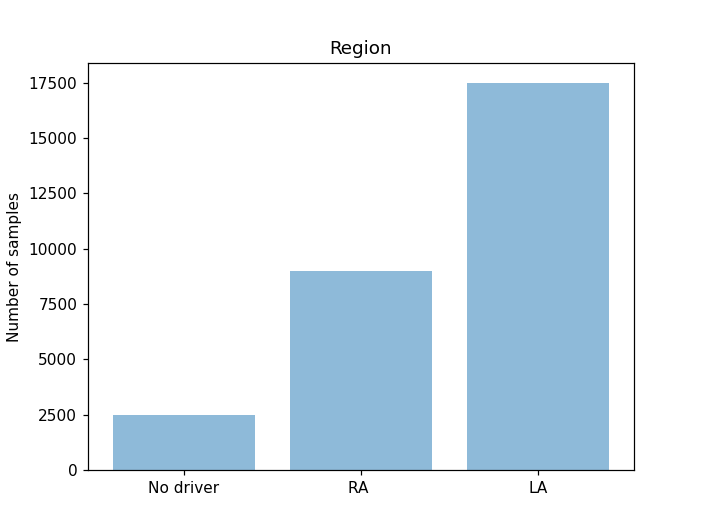

In [14]:
#bar plot
from collections import Counter
a = Counter(Y)
count = [a[0],a[1],a[2]]
labels = ("No driver","RA ","LA")
#plt.pie(count, labels=nombres)
#plt.axis('equal')
#plt.show()

y_pos = np.arange(len(labels))
performance = count
plt.figure()
plt.bar(y_pos, performance, align='center', alpha=0.5)
plt.xticks(y_pos, labels)
plt.ylabel('Number of samples')
plt.title('Region')
plt.show()

[0 1 2]


<IPython.core.display.Javascript object>


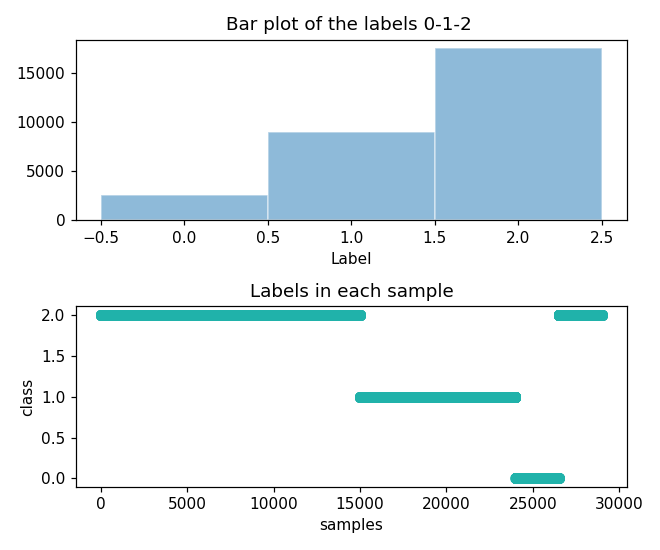

In [8]:
print(np.unique(Y))

# bar diagram

data=Y
d = np.diff(np.unique(data)).min()
left_of_first_bin = data.min() - float(d)/2
right_of_last_bin = data.max() + float(d)/2

plt.figure(figsize=(6,5), layout='tight')
plt.subplot(2,1,1)
plt.hist(data, np.arange(left_of_first_bin, right_of_last_bin + d, d), alpha=0.5, histtype='bar', ec='white')
plt.xlabel('Label')
plt.title('Bar plot of the labels 0-1-2 ')
plt.subplot(2,1,2)

plt.plot(Y, 'o', c='lightseagreen')
plt.title('Labels in each sample')
plt.xlabel('samples')
plt.ylabel('class')
plt.show()

<IPython.core.display.Javascript object>


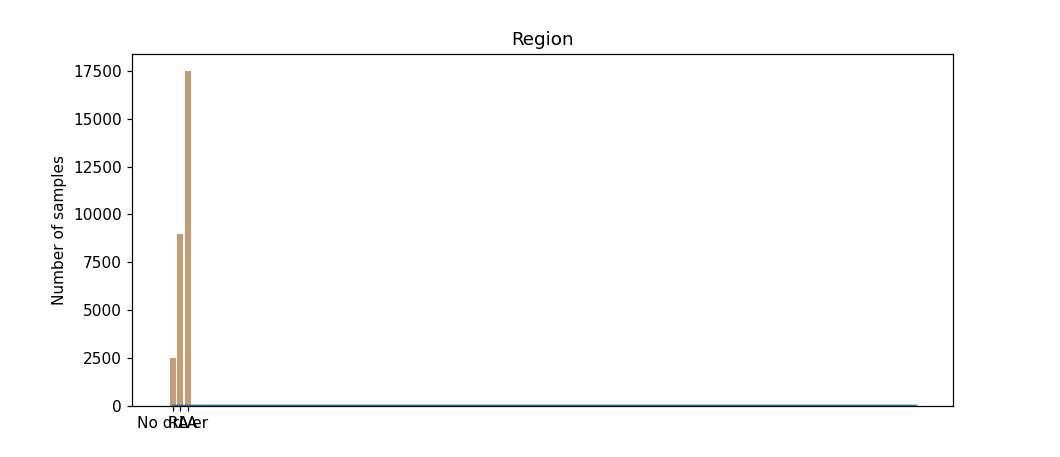

In [11]:
plt.figure()
plt.plot(X[1:100, 1])
plt.show()

# Cross validation

Mode_CV={1,2,3,4}

* 1: K fold by sets of BSPS: 75% of models (9 models) for train and 4 for test
* 2: By Models: Each model is split into Train/Test
* 3: By batches and sequentially (Test always the last)--> 1º) Batches 
* 4: By batches, not sequential --> 1º) Batches 
* 5: BY AF Models: Train with ~75% of the AF Models (AF Models --> 1-13) and test with the rest

Hyperparameters to tune:

* sequential (True/False)--> If Test is always at the end
* n_folds (def=5) --> Number of folds
* shuffle_batches_train (True/False)--> If batches in Train (Modes 1/2) are shuffled
* shuffle_all_batches (True/False)--> If all batches are shuffled (Models 3/4)


In [9]:
#Parameters for CV
Mode=2
n_models=np.unique(Y_model)
n_folds=5
shuffle_batches_train = True
shuffle_all_batches=False
input_size=50
sequential=False

In [10]:
acc_per_fold, loss_per_fold, acc_per_fold_train, loss_per_fold_train, conf_matrix_test,conf_matrix_train, classif_report_list=generator_batches_RNN_CV(X,Y,Y_model,Mode,sequential,n_folds, shuffle_batches_train,shuffle_all_batches, input_size,n_labels = 8,fs=50, val=False )

2022-07-22 13:14:53.189861: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-07-22 13:14:53.190546: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-07-22 13:14:53.191011: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-07-22 13:14:53.191358: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so retur

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 50, 64)]     0           []                               
                                                                                                  
 reshape (Reshape)              (None, 2, 25, 64)    0           ['input_1[0][0]']                
                                                                                                  
 time_distributed (TimeDistribu  (None, 2, 21, 32)   10272       ['reshape[0][0]']                
 ted)                                                                                             
                                                                                                  
 time_distributed_1 (TimeDistri  (None, 2, 7, 32)    0           ['time_distributed[0][0]']   

2022-07-22 13:14:56.523110: I tensorflow/stream_executor/cuda/cuda_dnn.cc:366] Loaded cuDNN version 8201
2022-07-22 13:14:56.782972: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


450/450 [==============================] - 5s 5ms/step - loss: 1.6276 - acc: 0.4756 - cohen_kappa: 0.0824 - lr: 0.0010
Epoch 2/100
450/450 [==============================] - 2s 5ms/step - loss: 1.1047 - acc: 0.6422 - cohen_kappa: 0.2179 - lr: 0.0010
Epoch 3/100
450/450 [==============================] - 2s 5ms/step - loss: 0.8147 - acc: 0.7267 - cohen_kappa: 0.4152 - lr: 0.0010
Epoch 4/100
450/450 [==============================] - 2s 5ms/step - loss: 0.5952 - acc: 0.7844 - cohen_kappa: 0.5592 - lr: 0.0010
Epoch 5/100
450/450 [==============================] - 2s 5ms/step - loss: 0.5230 - acc: 0.8133 - cohen_kappa: 0.6224 - lr: 0.0010
Epoch 6/100
450/450 [==============================] - 2s 5ms/step - loss: 0.4331 - acc: 0.8400 - cohen_kappa: 0.6803 - lr: 0.0010
Epoch 7/100
450/450 [==============================] - 2s 5ms/step - loss: 0.3949 - acc: 0.8511 - cohen_kappa: 0.7088 - lr: 0.0010
Epoch 8/100
450/450 [==============================] - 2s 5ms/step - loss: 0.3512 - acc: 0.8644

320/320 [==============================] - 2s 5ms/step - loss: 0.5859 - acc: 0.7906 - cohen_kappa: 0.5934 - lr: 0.0010
Epoch 7/100
320/320 [==============================] - 2s 5ms/step - loss: 0.4704 - acc: 0.8469 - cohen_kappa: 0.7006 - lr: 0.0010
Epoch 8/100
320/320 [==============================] - 2s 5ms/step - loss: 0.4164 - acc: 0.8656 - cohen_kappa: 0.7435 - lr: 0.0010
Epoch 9/100
320/320 [==============================] - 2s 5ms/step - loss: 0.3791 - acc: 0.8687 - cohen_kappa: 0.7485 - lr: 0.0010
Epoch 10/100
320/320 [==============================] - 2s 5ms/step - loss: 0.3700 - acc: 0.8531 - cohen_kappa: 0.7209 - lr: 0.0010
Epoch 11/100
320/320 [==============================] - 2s 5ms/step - loss: 0.3337 - acc: 0.8750 - cohen_kappa: 0.7626 - lr: 0.0010
Epoch 12/100
320/320 [==============================] - 2s 5ms/step - loss: 0.3665 - acc: 0.8562 - cohen_kappa: 0.7244 - lr: 0.0010
Epoch 13/100
320/320 [==============================] - 2s 5ms/step - loss: 0.3861 - acc: 0.

Epoch 13/100
320/320 [==============================] - 1s 5ms/step - loss: 0.3382 - acc: 0.8562 - cohen_kappa: 0.7264 - lr: 0.0010
Epoch 14/100
320/320 [==============================] - 1s 5ms/step - loss: 0.3451 - acc: 0.8719 - cohen_kappa: 0.7577 - lr: 0.0010
Epoch 15/100
320/320 [==============================] - 1s 5ms/step - loss: 0.2992 - acc: 0.8750 - cohen_kappa: 0.7607 - lr: 0.0010
Epoch 16/100
320/320 [==============================] - 1s 5ms/step - loss: 0.2958 - acc: 0.8781 - cohen_kappa: 0.7688 - lr: 0.0010
Epoch 17/100
320/320 [==============================] - 1s 5ms/step - loss: 0.2596 - acc: 0.9219 - cohen_kappa: 0.8530 - lr: 0.0010
Epoch 18/100
320/320 [==============================] - 1s 5ms/step - loss: 0.2218 - acc: 0.9156 - cohen_kappa: 0.8420 - lr: 0.0010
Epoch 19/100
320/320 [==============================] - 1s 5ms/step - loss: 0.2154 - acc: 0.9062 - cohen_kappa: 0.8257 - lr: 0.0010
Epoch 20/100
320/320 [==============================] - 1s 5ms/step - loss: 

<IPython.core.display.Javascript object>


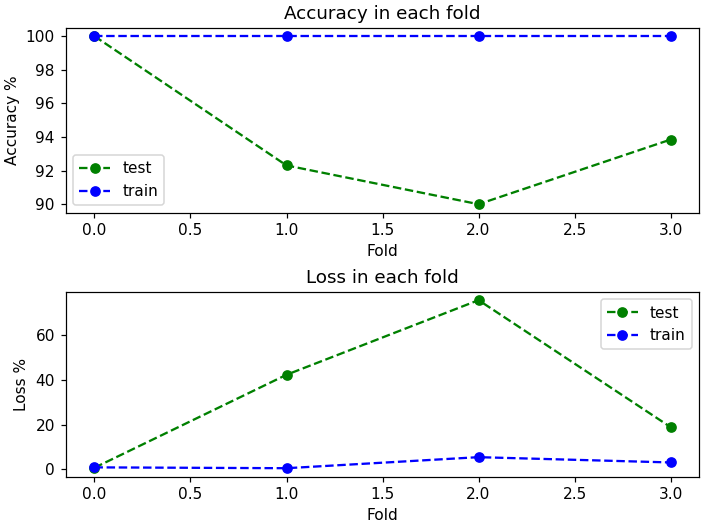

Mean for the 5 Folds: 94.03846114873886 +- 4.277135892683419


In [11]:
#Mean and standard deviation PLOT
plt.figure(constrained_layout=True)
plt.subplot(2,1,1)
plt.plot(acc_per_fold, '--go', label='test')
plt.plot(acc_per_fold_train, '--bo', label='train')
plt.xlabel('Fold')
plt.ylabel('Accuracy %')
plt.legend()
plt.title('Accuracy in each fold')
plt.subplot(2,1,2)
plt.plot(loss_per_fold, '--go', label='test')
plt.plot(loss_per_fold_train, '--bo', label='train')
plt.xlabel('Fold')
plt.ylabel('Loss %')
plt.legend()
plt.title('Loss in each fold')
plt.show()

#####
import statistics 
mean_accuracy= statistics.mean(acc_per_fold)
std_accuracy= statistics.stdev(acc_per_fold)
print('Mean for the',n_folds, 'Folds:', mean_accuracy, '+-',std_accuracy)


In [12]:
acc_per_fold

[100.0, 92.30769276618958, 89.99999761581421, 93.84615421295166]

In [13]:
from sklearn.preprocessing import normalize
norm=[]
for i in conf_matrix_test:
    norm.extend([(i/i.sum(axis=1))])
    
mean_matrix=np.mean(norm, axis=0)
std_matrix=np.std(norm, axis=0)
print(norm)

[array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), array([[1.   , 0.   , 0.   ],
       [0.   , 0.75 , 0.125],
       [0.   , 0.   , 1.   ]]), array([[1.    , 0.    , 0.    ],
       [0.    , 0.725 , 0.1375],
       [0.    , 0.05  , 0.975 ]]), array([[0.8  , 0.   , 0.025],
       [0.   , 0.85 , 0.075],
       [0.   , 0.   , 1.   ]])]


In [14]:
import pandas as pd
#mean metrics by region
#create dataset
arr_df=np.empty([n_labels,3,4])
df_results=pd.DataFrame(columns=['Precision','Recall', 'F1', 'Support'])

for fold in range(0, len(classif_report_list)):
    metrics=classif_report_list[fold][0]
    for region in metrics:
        if region== '0' or region== '1' or region== '2' or region== '3' or region== '4' or region== '5':
           
            arr_df[int(region), 0, fold]=metrics[region]['precision']
            arr_df[int(region), 1, fold]=metrics[region]['recall']
            arr_df[int(region), 2, fold]=metrics[region]['f1-score']
        else:
            continue
average_arr=np.empty([n_labels, 6])

for region in range(0, len(arr_df)):
    
    average_arr[region,0]=round(np.average(arr_df[region,0], axis=0),2)
    average_arr[region,1]=round(np.std(arr_df[region,0], axis=0),2)
    average_arr[region,2]=round(np.average(arr_df[region,1], axis=0),2)
    average_arr[region,3]=round(np.std(arr_df[region,1], axis=0),2)
    average_arr[region,4]=round(np.average(arr_df[region,2],axis=0),2)
    average_arr[region,5]=round(np.std(arr_df[region,2],axis=0),2)

    
metrics_df=pd.DataFrame(average_arr, columns=['Precision','Precision STD','Recall','Recall STD', 'F1', 'F1 STD'])
metrics_df.head(10)        
        

,Precision,Precision STD,Recall,Recall STD,F1,F1 STD
0,1.00,0.00,0.95,0.09,0.97,0.05
1,0.98,0.03,0.83,0.11,0.90,0.07
2,0.92,0.05,0.99,0.01,0.95,0.03


In [15]:
precision=[]
recall=[]
f1=[]
for region in range(0,n_labels):
    precision.extend([arr_df[region][0]])
    recall.extend([arr_df[region][1]])
    f1.extend([arr_df[region][2]])
    


<IPython.core.display.Javascript object>


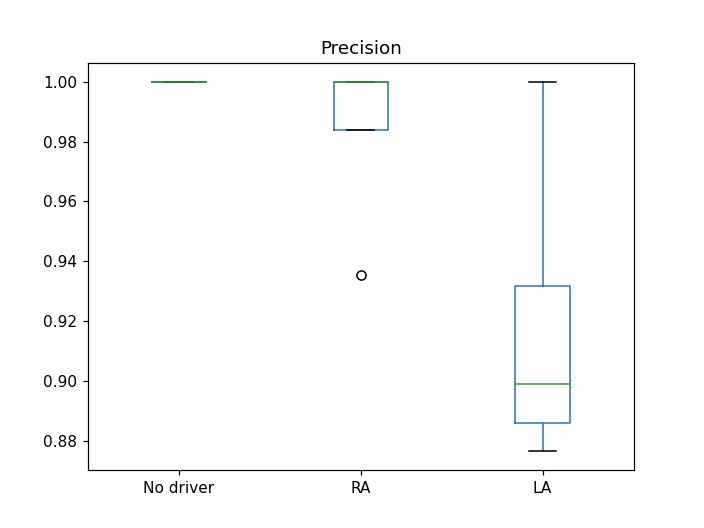

<IPython.core.display.Javascript object>


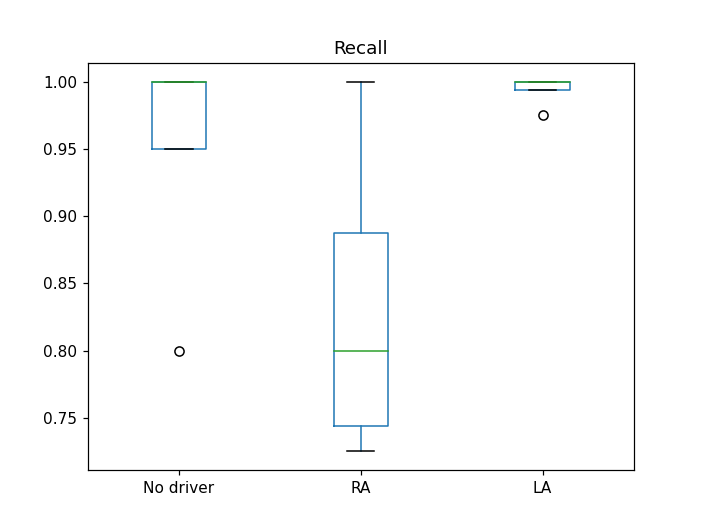

<IPython.core.display.Javascript object>


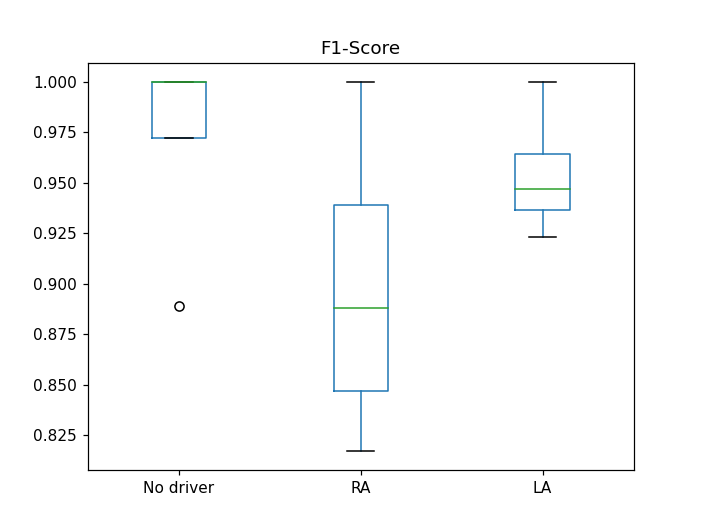

In [16]:
#Precision
if n_classes ==3:
    cols= ['No driver', 'R1', 'R2', 'R3', 'R4', 'R5']
if n_classes ==2:
    cols= ['No driver', 'RA', 'LA']
    
df=pd.DataFrame(precision).T
df.head(10)
df.columns =cols
plt.figure()
boxplot = df.boxplot(column=cols, grid=False) 
boxplot.plot()
plt.title('Precision')
plt.show()
#Precision
df=pd.DataFrame(recall).T
df.head(10)
df.columns =cols
plt.figure()
boxplot = df.boxplot(column=cols, grid=False) 
boxplot.plot()
plt.title('Recall')
plt.show()
#Precision
df=pd.DataFrame(f1).T
df.head(10)
df.columns =cols
plt.figure()
boxplot = df.boxplot(column=cols, grid=False)  
boxplot.plot()
plt.title('F1-Score')
plt.show()

<IPython.core.display.Javascript object>


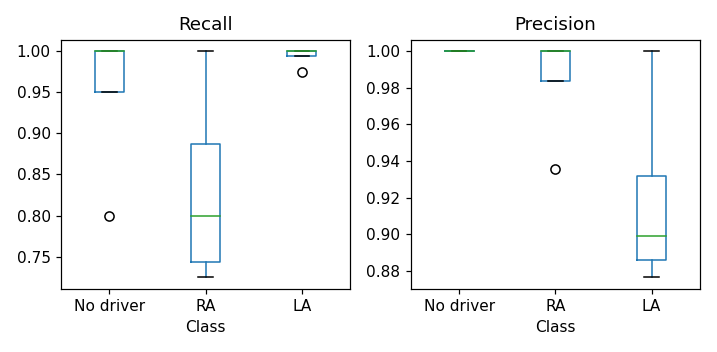

Text(0.5, 1.0, 'Precision')

In [17]:
plt.figure(layout='tight')
plt.subplot(1,2,1)
df=pd.DataFrame(recall).T
df.head(10)
df.columns =cols
boxplot = df.boxplot(column=cols, grid=False) 
boxplot.plot()
plt.title('Recall')
plt.xlabel('Class')

plt.subplot(1,2,2)
df=pd.DataFrame(precision).T
df.head(10)
df.columns =cols
boxplot = df.boxplot(column=cols, grid=False) 
plt.xlabel('Class')
boxplot.plot()
plt.title('Precision')

<IPython.core.display.Javascript object>


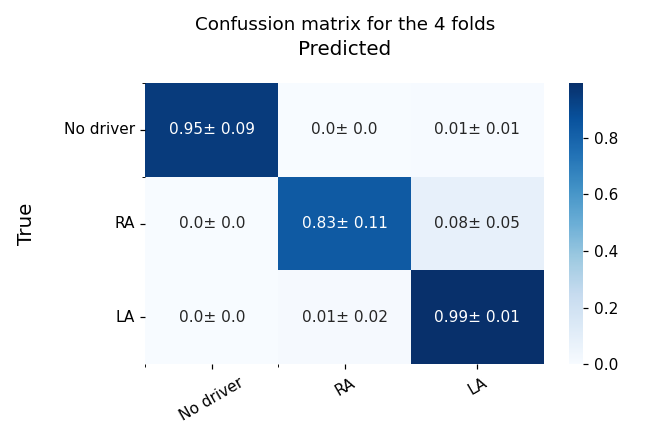

In [18]:
import seaborn as sns



mean_mat= pd.DataFrame(mean_matrix, index = cols,
                  columns = cols)
std_mat= pd.DataFrame(std_matrix, index = cols,
                  columns = cols)
df_labels=pd.DataFrame(index = cols,columns = cols)
df_labels['No driver']=round(mean_mat['No driver'],2).astype(str) +"± "+round(std_mat['No driver'],2).astype(str)
df_labels['RA']=round(mean_mat['RA'],2).astype(str) +"± "+round(std_mat['RA'],2).astype(str)
df_labels['LA']=round(mean_mat['LA'],2).astype(str) +"± "+round(std_mat['LA'],2).astype(str)

plt.figure(figsize = (6,4), layout= 'tight')
ax = plt.subplot()
sns.heatmap(mean_mat,annot=df_labels,fmt="", cmap="Blues",ax = ax)
ax.set_xticks(range(n_classes),minor=True)
ax.set_yticks(range(n_classes),minor=True)
ax.set_xticklabels(cols,fontsize = 10,rotation=30, va='top',ha="center")
ax.set_yticklabels(cols,fontsize = 10,rotation=0)
ax.set_xlabel('Predicted\n', fontsize = 13)
ax.set_ylabel('True\n', fontsize=13)
ax.xaxis.set_label_position('top')
plt.tight_layout()
plt.title('Confussion matrix for the 4 folds')
plt.show()
